# Реализация кода из статьи Google [How Important Is a Neuron?](https://arxiv.org/abs/1805.12233)

In [21]:
import math
import gc

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
from torch.func import jvp

torch.set_grad_enabled(True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")
DTYPE = torch.float32

print("device:", DEVICE)
print("torch:", torch.__version__)

device: mps
torch: 2.9.1


In [22]:
# Загрузка классификатора
yolo = YOLO("yolo11s-cls.pt")
model = yolo.model.to(DEVICE).eval()
class_names = yolo.names

print(type(model).__name__)
print("num classes:", len(class_names))
print("first 10 classes:", {k: class_names[k] for k in range(10)})

ClassificationModel
num classes: 1000
first 10 classes: {0: 'tench', 1: 'goldfish', 2: 'great_white_shark', 3: 'tiger_shark', 4: 'hammerhead', 5: 'electric_ray', 6: 'stingray', 7: 'cock', 8: 'hen', 9: 'ostrich'}


In [23]:
IMG_SIZE = 224
DEFAULT_LAYER_NAME = "model.9"

def load_image(path, img_size=IMG_SIZE, pad_value=0.0):
    img = Image.open(path).convert("RGB")
    img_np = np.asarray(img).astype(np.float32) / 255.0
    h, w = img_np.shape[:2]
    if h == 0 or w == 0:
        raise ValueError(f"Некорректный размер изображения: {(h, w)}")

    scale = img_size / max(h, w)
    new_h = max(1, int(round(h * scale)))
    new_w = max(1, int(round(w * scale)))

    resized = np.asarray(
        Image.fromarray((img_np * 255).astype(np.uint8)).resize((new_w, new_h), Image.Resampling.BILINEAR)
    ).astype(np.float32) / 255.0

    canvas = np.full((img_size, img_size, 3), pad_value, dtype=np.float32)
    top = (img_size - new_h) // 2
    left = (img_size - new_w) // 2
    canvas[top:top + new_h, left:left + new_w] = resized

    x = torch.from_numpy(canvas).permute(2, 0, 1).unsqueeze(0).to(DEVICE, DTYPE)
    return x, canvas


def black_baseline_like(x):
    return torch.zeros_like(x)

def list_named_modules(model):
    return [(name, module) for name, module in model.named_modules() if name != ""]

def clear_backend_cache():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch, "mps") and torch.mps.is_available():
        try:
            torch.mps.empty_cache()
        except Exception:
            pass

print("default layer:", DEFAULT_LAYER_NAME)

default layer: model.9


In [24]:
# Вспомогательные утилиты для layer hook, output parsing и plotting

def split_classifier_output(out):
    if isinstance(out, (tuple, list)):
        if len(out) >= 2 and torch.is_tensor(out[1]):
            return out[0], out[1]
        if len(out) >= 1 and torch.is_tensor(out[0]):
            return None, out[0]
    if torch.is_tensor(out):
        return None, out
    raise TypeError(f"Не удалось интерпретировать output классификатора типа {type(out).__name__}")

def unwrap_tensor(output):
    if torch.is_tensor(output):
        return output
    if isinstance(output, (list, tuple)):
        for item in output:
            if torch.is_tensor(item):
                return item
    raise TypeError(f"Не удалось извлечь tensor activation из output типа {type(output).__name__}")

class LayerHook:
    def __init__(self, model, layer_name):
        self.layer_name = layer_name
        self.layer_store = {}
        modules = dict(model.named_modules())
        if layer_name not in modules:
            raise KeyError(f"Слой '{layer_name}' не найден в model.named_modules()")
        self.handle = modules[layer_name].register_forward_hook(self._hook)

    def _hook(self, module, inp, out):
        self.layer_store[self.layer_name] = out

    def clear(self):
        self.layer_store.clear()

    def get(self):
        return self.layer_store[self.layer_name]

    def remove(self):
        self.handle.remove()

def reduce_filter_scores(cond_tensor):
    if cond_tensor.ndim < 2:
        raise ValueError(
            f"Ожидался tensor с batch-осью и хотя бы одной feature-осью, получено shape={tuple(cond_tensor.shape)}"
        )

    per_sample = cond_tensor[0]
    if per_sample.ndim == 1:
        return per_sample

    reduce_dims = tuple(range(1, per_sample.ndim))
    return per_sample.sum(dim=reduce_dims)

def _normalize_map(arr):
    arr = arr.astype(np.float32)
    max_abs = np.max(np.abs(arr))
    if max_abs > 0:
        arr = arr / max_abs
    return arr

def _resize_map_nearest(arr, out_hw):
    # Без сглаживания: nearest-neighbor upsampling
    h_out, w_out = out_hw
    h_in, w_in = arr.shape

    row_idx = np.floor(np.arange(h_out) * (h_in / h_out)).astype(int)
    col_idx = np.floor(np.arange(w_out) * (w_in / w_out)).astype(int)

    row_idx = np.clip(row_idx, 0, h_in - 1)
    col_idx = np.clip(col_idx, 0, w_in - 1)

    return arr[row_idx][:, col_idx]

def plot_total_conductance_overlay(image_np, cond_tensor, title=None):
    cond_np = cond_tensor[0].detach().cpu().numpy()

    if cond_np.ndim < 3:
        print("Общий spatial plot пропущен: у слоя нет пространственных осей.")
        return

    # Общая spatial conductance:
    # сумма по фильтрам |Cond_{c,h,w}|
    total_map = cond_np.sum(axis=0)
    total_map = _normalize_map(total_map)
    total_map = _resize_map_nearest(total_map, image_np.shape[:2])

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image_np, interpolation="nearest")
    heat = ax.imshow(total_map, cmap="seismic", vmin=-1.0, vmax=1.0, alpha=0.45, interpolation="nearest")
    ax.axis("off")
    ax.set_title(title or "Total conductance overlay")

    cbar = fig.colorbar(heat, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Normalized conductance", rotation=90)

    plt.show()

def plot_top_filter_overlays(image_np, cond_tensor, filter_scores, top_idx, top_n=5):
    cond_np = cond_tensor[0].detach().cpu().numpy()

    if cond_np.ndim < 3:
        print("Spatial overlays для отдельных фильтров пропущены: у слоя нет пространственных осей.")
        return

    top_n = min(top_n, len(top_idx))

    for rank, idx in enumerate(top_idx[:top_n].tolist(), start=1):
        fmap = cond_np[idx]
        fmap = _normalize_map(fmap)
        fmap = _resize_map_nearest(fmap, image_np.shape[:2])

        plt.figure(figsize=(6, 6))
        plt.imshow(image_np, interpolation="nearest")
        plt.imshow(fmap, cmap="seismic", vmin=-1.0, vmax=1.0, alpha=0.45, interpolation="nearest")
        plt.title(f"Filter {idx} conductance = {float(filter_scores[idx]):+.6f} (rank {rank})")
        plt.show()

In [25]:
# Conductance по статье:
#
# x(α) = x0 + α (x - x0)
# F(x(α)) = logit целевого класса
# y(α) = activation выбранного слоя
#
# Cond(y) = ∫_0^1 [ ∂F/∂y (x(α)) · dy/dα (α) ] dα
#
# Здесь:
# - grad_y = ∂F/∂y
# - act_tangent = dy/dα
# - integrand = grad_y * act_tangent
#
# Численное интегрирование: midpoint rule

def compute_conductance(
    model,
    hook,
    x,
    x0,
    target_class,
    n_steps=64,
    fd_eps=1e-3,
    clear_every=8,
):
    x = x.contiguous()
    x0 = x0.contiguous()
    delta_x = (x - x0).contiguous()

    def forward_with_layer(x_in):
        hook.clear()
        out = model(x_in)
        act = unwrap_tensor(hook.get())
        return out, act

    alphas = torch.linspace(0.0, 1.0, n_steps + 1, device=x.device, dtype=x.dtype)
    step = 1.0 / n_steps

    cond_accum = None
    used_fallback = False

    for k in range(n_steps):
        alpha = (alphas[k] + alphas[k + 1]) / 2.0
        x_alpha = (x0 + alpha * delta_x).contiguous().detach().requires_grad_(True)

        out, act = forward_with_layer(x_alpha)
        _, logits = split_classifier_output(out)
        score = logits[0, target_class]

        # ∂F/∂y
        grad_y = torch.autograd.grad(score, act, retain_graph=False, create_graph=False)[0]

        try:
            def act_only(inp):
                inp = inp.contiguous()
                _, a = forward_with_layer(inp)
                return a

            # dy/dα
            _, act_tangent = jvp(act_only, (x_alpha,), (delta_x,))

        except RuntimeError as e:
            if "view size is not compatible with input tensor's size and stride" not in str(e):
                raise

            used_fallback = True

            alpha_plus = min(float(alpha.item()) + fd_eps, 1.0)
            alpha_minus = max(float(alpha.item()) - fd_eps, 0.0)
            denom = alpha_plus - alpha_minus

            if denom == 0.0:
                raise RuntimeError("Не удалось построить finite-difference fallback для dy/dalpha.")

            with torch.no_grad():
                _, act_plus = forward_with_layer((x0 + alpha_plus * delta_x).contiguous())
                _, act_minus = forward_with_layer((x0 + alpha_minus * delta_x).contiguous())

            # dy/dα ≈ [y(α+ε) - y(α-ε)] / (2ε)
            act_tangent = (act_plus - act_minus) / denom
            del act_plus, act_minus

        integrand = grad_y * act_tangent
        cond_accum = integrand.detach() if cond_accum is None else (cond_accum + integrand.detach())

        del x_alpha, out, act, logits, score, grad_y, act_tangent, integrand
        hook.clear()

        if (k + 1) % clear_every == 0:
            clear_backend_cache()

    cond = cond_accum * step
    clear_backend_cache()

    if used_fallback:
        print("Предупреждение: jvp на текущем backend не сработал, для dy/dalpha использована конечная разность.")

    return cond.detach()

In [26]:
def run_conductance_pipeline(
    image_path,
    layer_name=DEFAULT_LAYER_NAME,
    n_steps=64,
    top_n=5,
    fd_eps=1e-3,
    clear_every=8,
):
    x, img_np = load_image(image_path)
    x0 = black_baseline_like(x)

    hook = LayerHook(model, layer_name)

    try:
        def forward_with_layer(x_in):
            hook.clear()
            out = model(x_in)
            act = unwrap_tensor(hook.get())
            return out, act

        with torch.no_grad():
            out, act = forward_with_layer(x)
            probs, logits = split_classifier_output(out)
            target_class = int(logits[0].argmax().item())
            target_name = class_names[target_class]
            target_logit = float(logits[0, target_class].item())
            target_prob = float(torch.softmax(logits[0], dim=0)[target_class].item())

        cond_tensor = compute_conductance(
            model=model,
            hook=hook,
            x=x,
            x0=x0,
            target_class=target_class,
            n_steps=n_steps,
            fd_eps=fd_eps,
            clear_every=clear_every,
        )

        filter_scores = reduce_filter_scores(cond_tensor)
        layer_score = cond_tensor.sum()

        topk = min(10, filter_scores.numel())
        top_vals, top_idx = torch.topk(filter_scores, k=topk)

        with torch.no_grad():
            out_x, _ = forward_with_layer(x)
            out_x0, _ = forward_with_layer(x0)

            _, logits_x = split_classifier_output(out_x)
            _, logits_x0 = split_classifier_output(out_x0)

            fx = float(logits_x[0, target_class].item())
            fx0 = float(logits_x0[0, target_class].item())
            abs_error = abs((fx - fx0) - float(layer_score.item()))

        print("image:", image_path)
        print("layer:", layer_name)
        print("target class:", target_class, target_name)
        print("target logit:", target_logit)
        print("target softmax prob:", target_prob)
        print("layer activation shape:", tuple(act.shape))
        print("cond tensor shape:", tuple(cond_tensor.shape))
        print("filter_scores shape:", tuple(filter_scores.shape))

        print("\ntop filters by |conductance|:")
        for rank, idx in enumerate(top_idx.tolist(), start=1):
            val = float(filter_scores[idx].item())
            print(f"{rank:2d}. filter {idx:4d}: {val:+.6f}")

        print("\nlayer conductance sum:", float(layer_score.item()))
        print("example neuron conductance:", float(cond_tensor.reshape(-1)[0].item()))
        print("example filter conductance:", float(filter_scores[0].item()))
        print("F(x)            =", fx)
        print("F(x0)           =", fx0)
        print("F(x) - F(x0)    =", fx - fx0)
        print("sum conductance =", float(layer_score.item()))
        print("abs error       =", abs_error)

        plot_total_conductance_overlay(
            img_np,
            cond_tensor,
            title=f"Total conductance, layer={layer_name}, class={target_name}",
        )
        plot_top_filter_overlays(
            img_np,
            cond_tensor,
            filter_scores,
            top_idx,
            top_n=top_n,
        )

        result = {
            "image_path": image_path,
            "layer_name": layer_name,
            "target_class": target_class,
            "target_name": target_name,
            "target_logit": target_logit,
            "target_prob": target_prob,
            "activation_shape": tuple(act.shape),
            "cond_tensor": cond_tensor,
            "filter_scores": filter_scores,
            "layer_score": layer_score,
            "top_idx": top_idx,
            "top_vals": top_vals,
            "fx": fx,
            "fx0": fx0,
            "abs_error": abs_error,
        }
        return result

    finally:
        hook.remove()
        clear_backend_cache()

image: data/jess.jpg
layer: model.5
target class: 151 Chihuahua
target logit: 12.821250915527344
target softmax prob: 0.4234117269515991
layer activation shape: (1, 256, 14, 14)
cond tensor shape: (1, 256, 14, 14)
filter_scores shape: (256,)

top filters by |conductance|:
 1. filter  125: +1.079022
 2. filter   35: +0.930632
 3. filter   60: +0.728098
 4. filter   33: +0.707265
 5. filter  119: +0.660078
 6. filter  220: +0.587522
 7. filter  187: +0.574003
 8. filter  237: +0.524243
 9. filter  113: +0.507333
10. filter   37: +0.503947

layer conductance sum: 11.832696914672852
example neuron conductance: -3.9468986869906075e-06
example filter conductance: 0.33298054337501526
F(x)            = 12.821250915527344
F(x0)           = -0.4234539270401001
F(x) - F(x0)    = 13.244704842567444
sum conductance = 11.832696914672852
abs error       = 1.4120079278945923


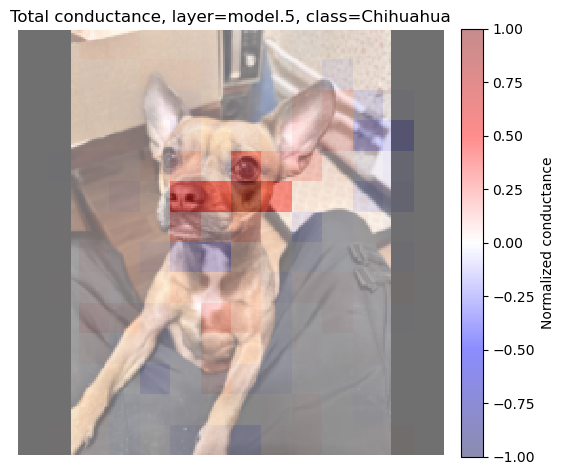

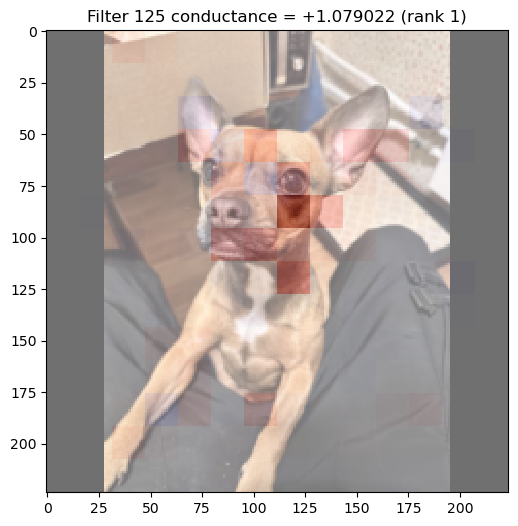

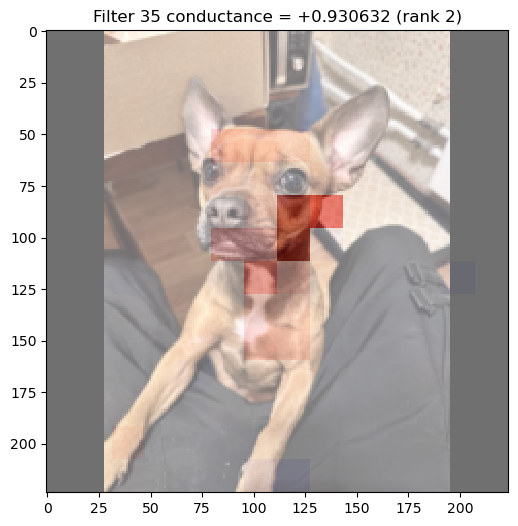

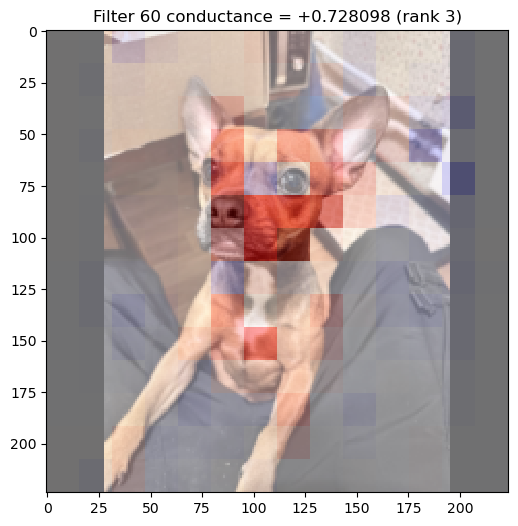

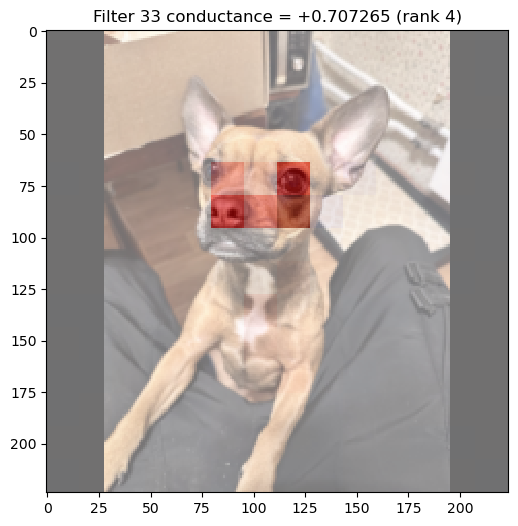

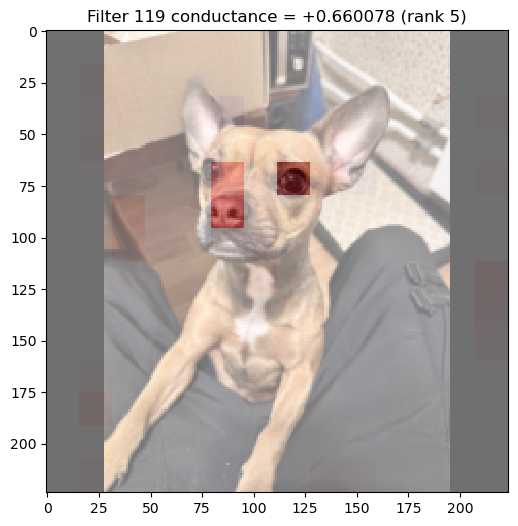

In [38]:
# %%
# Для классификатора предпоследний перед головой слой - 9
# Он слишком большой, 5 даёт достаточно хорошие признаки
result = run_conductance_pipeline(
    image_path="data/jess.jpg",
    layer_name='model.5',
    n_steps=128,
    top_n=5,
)

image: data/fox.jpg
layer: model.6
target class: 277 red_fox
target logit: 18.66610336303711
target softmax prob: 0.847356379032135
layer activation shape: (1, 256, 14, 14)
cond tensor shape: (1, 256, 14, 14)
filter_scores shape: (256,)

top filters by |conductance|:
 1. filter   68: +1.216696
 2. filter  137: +1.205859
 3. filter   85: +1.162752
 4. filter  127: +1.136035
 5. filter  200: +0.977432
 6. filter   51: +0.924261
 7. filter  225: +0.858161
 8. filter  223: +0.850000
 9. filter  241: +0.836698
10. filter   92: +0.761864

layer conductance sum: 16.6961669921875
example neuron conductance: -3.6457017813518178e-06
example filter conductance: 0.03272541984915733
F(x)            = 18.66610336303711
F(x0)           = 1.7859272956848145
F(x) - F(x0)    = 16.880176067352295
sum conductance = 16.6961669921875
abs error       = 0.18400907516479492


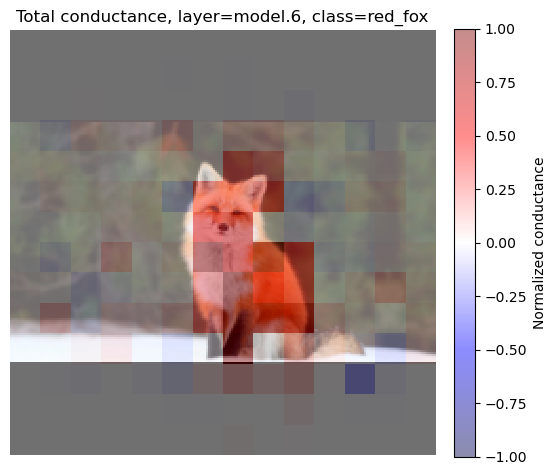

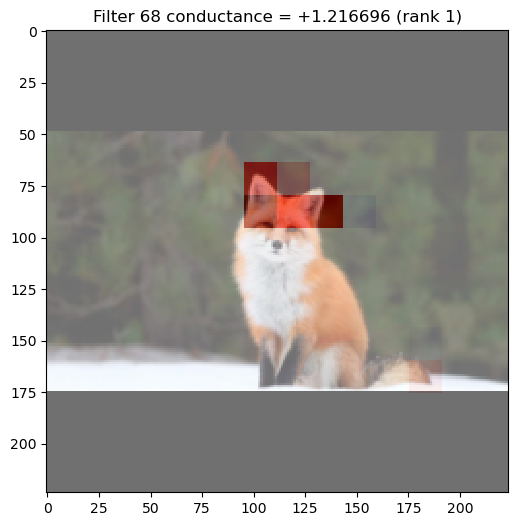

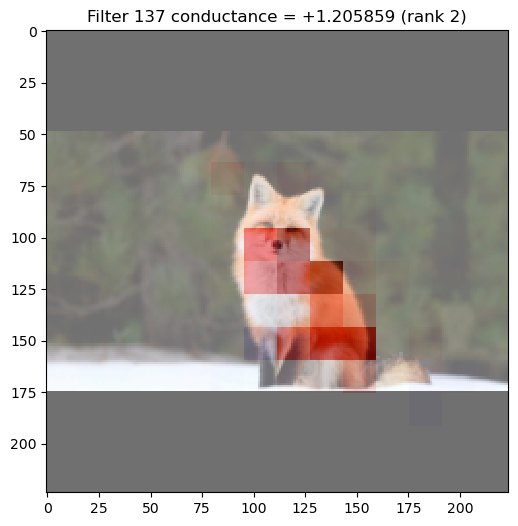

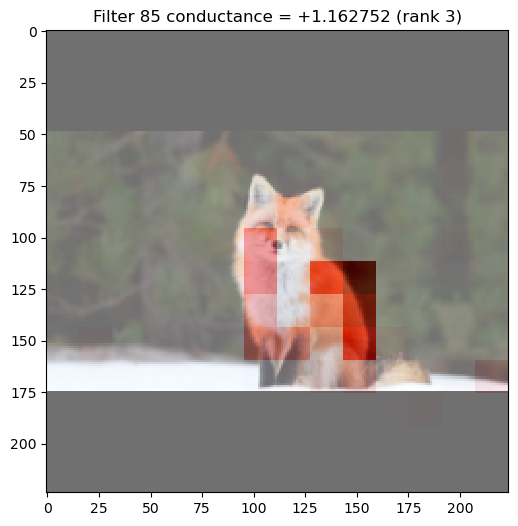

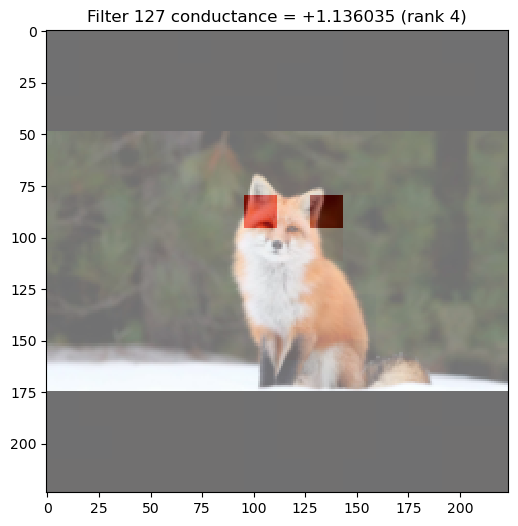

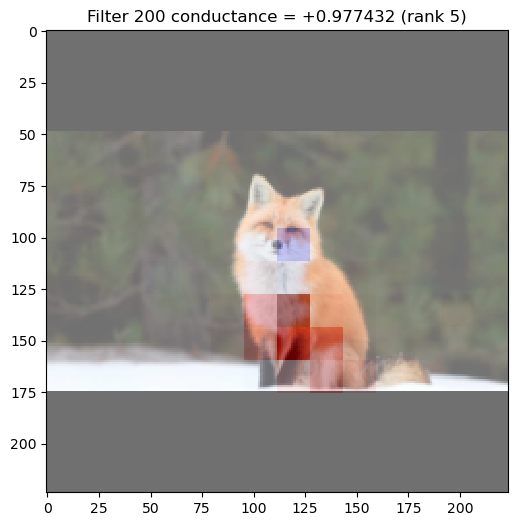

In [35]:
result = run_conductance_pipeline(
    image_path="data/fox.jpg",
    layer_name='model.6',
    n_steps=128,
    top_n=5,
)

image: data/fox.jpg
layer: model.9
target class: 277 red_fox
target logit: 18.66610336303711
target softmax prob: 0.847356379032135
layer activation shape: (1, 512, 7, 7)
cond tensor shape: (1, 512, 7, 7)
filter_scores shape: (512,)

top filters by |conductance|:
 1. filter  366: +2.665390
 2. filter  133: +1.372424
 3. filter  382: +1.296665
 4. filter   93: +0.856446
 5. filter  308: +0.715912
 6. filter   18: +0.635943
 7. filter  142: +0.583936
 8. filter  181: +0.581114
 9. filter  211: +0.553666
10. filter  173: +0.476938

layer conductance sum: 16.6961669921875
example neuron conductance: -0.000403119542170316
example filter conductance: 0.06899430602788925
F(x)            = 18.66610336303711
F(x0)           = 1.7859272956848145
F(x) - F(x0)    = 16.880176067352295
sum conductance = 16.6961669921875
abs error       = 0.18400907516479492


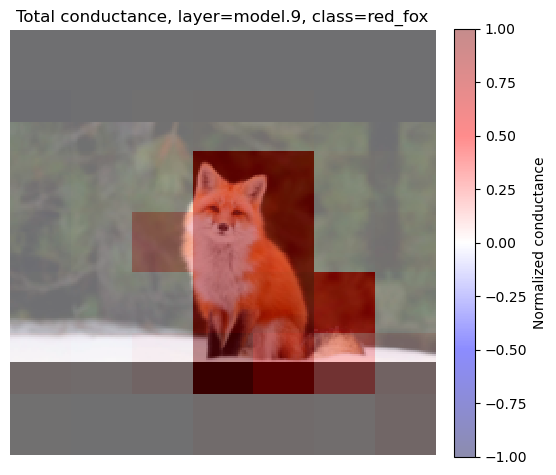

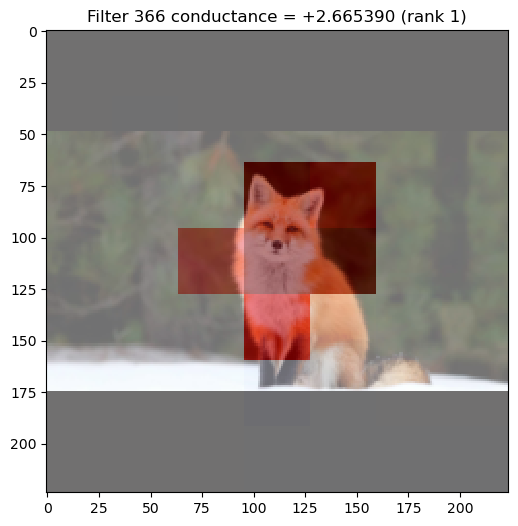

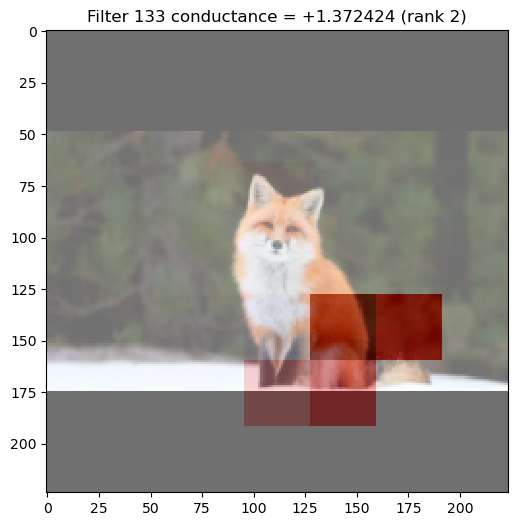

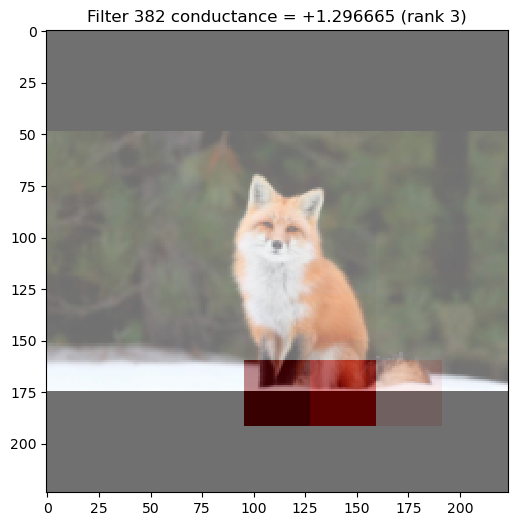

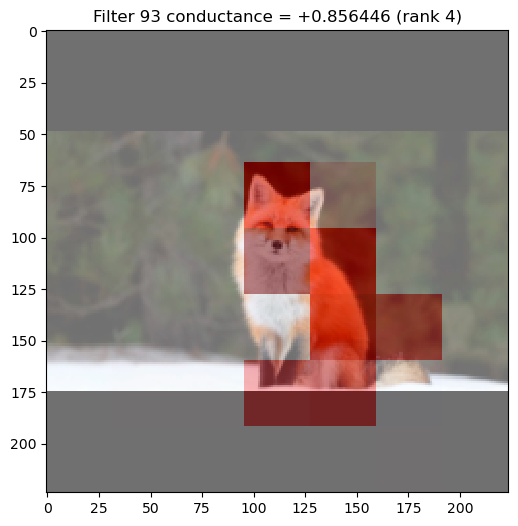

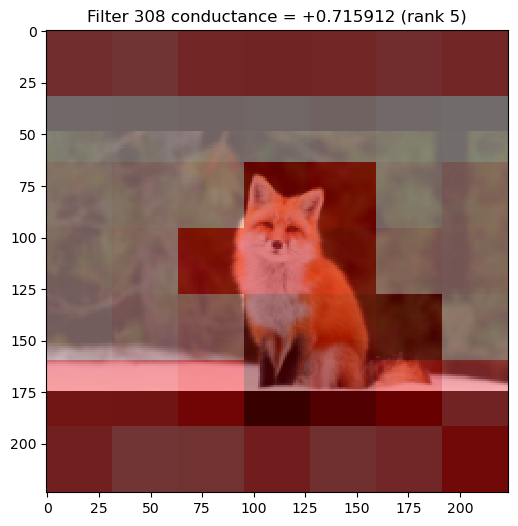

In [32]:
result = run_conductance_pipeline(
    image_path="data/fox.jpg",
    layer_name='model.9',
    n_steps=128,
    top_n=5,
)

image: data/lighthouse.jpg
layer: model.6
target class: 437 beacon
target logit: 13.793744087219238
target softmax prob: 0.7471544742584229
layer activation shape: (1, 256, 14, 14)
cond tensor shape: (1, 256, 14, 14)
filter_scores shape: (256,)

top filters by |conductance|:
 1. filter  114: +1.116402
 2. filter   88: +1.112473
 3. filter   14: +1.082009
 4. filter   60: +1.065614
 5. filter   99: +0.855080
 6. filter  160: +0.757997
 7. filter   27: +0.752404
 8. filter   77: +0.684086
 9. filter  169: +0.683035
10. filter   38: +0.647490

layer conductance sum: 13.282758712768555
example neuron conductance: -2.224645868409425e-05
example filter conductance: 0.07919661700725555
F(x)            = 13.793744087219238
F(x0)           = -0.3120385706424713
F(x) - F(x0)    = 14.10578265786171
sum conductance = 13.282758712768555
abs error       = 0.8230239450931549


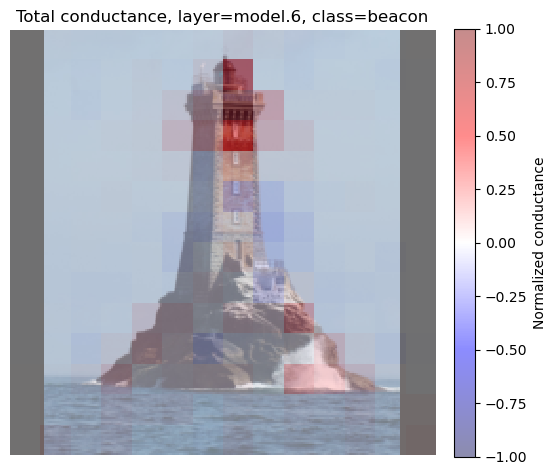

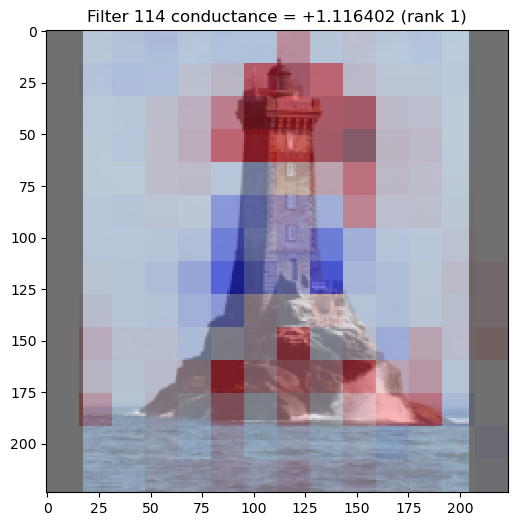

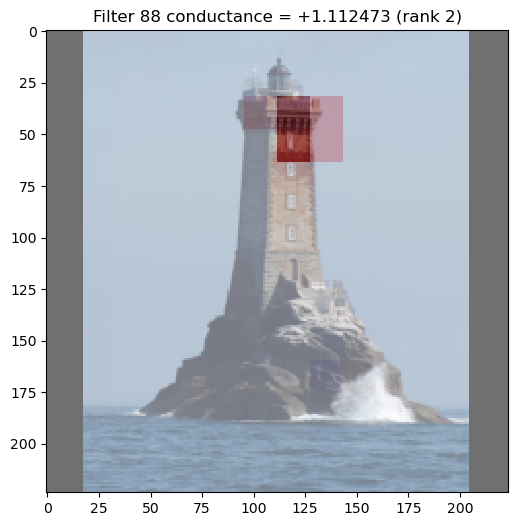

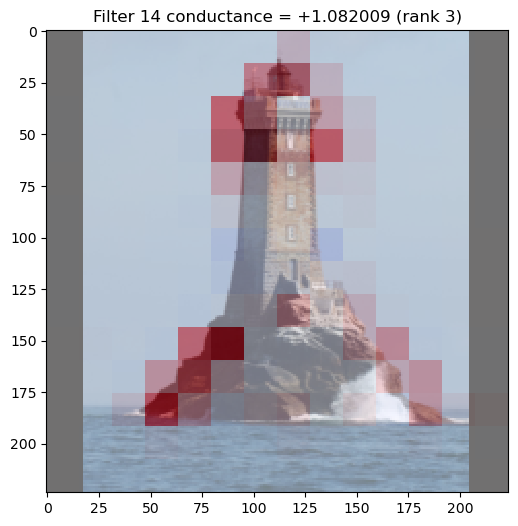

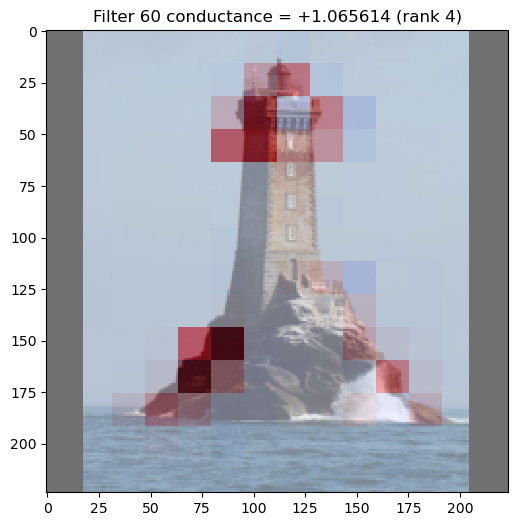

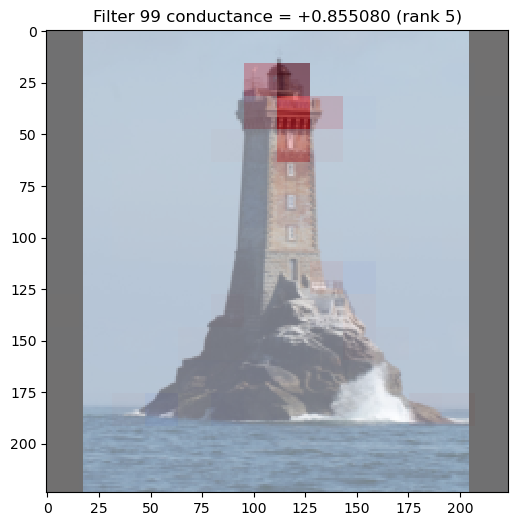

In [33]:
result = run_conductance_pipeline(
    image_path="data/lighthouse.jpg",
    layer_name='model.6',
    n_steps=128,
    top_n=5,
)

image: data/lighthouse.jpg
layer: model.0
target class: 437 beacon
target logit: 13.793744087219238
target softmax prob: 0.7471544742584229
layer activation shape: (1, 32, 112, 112)
cond tensor shape: (1, 32, 112, 112)
filter_scores shape: (32,)

top filters by |conductance|:
 1. filter   29: +4.380157
 2. filter    3: +4.059181
 3. filter   23: +2.505146
 4. filter   28: +2.354543
 5. filter   16: +1.634992
 6. filter   14: +1.282305
 7. filter   17: +1.229581
 8. filter    1: +1.100271
 9. filter   25: +0.894627
10. filter    7: +0.661883

layer conductance sum: 13.282758712768555
example neuron conductance: 0.0
example filter conductance: -0.18527032434940338
F(x)            = 13.793744087219238
F(x0)           = -0.3120385706424713
F(x) - F(x0)    = 14.10578265786171
sum conductance = 13.282758712768555
abs error       = 0.8230239450931549


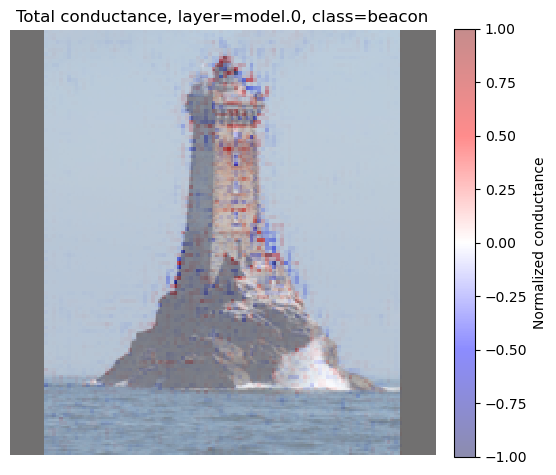

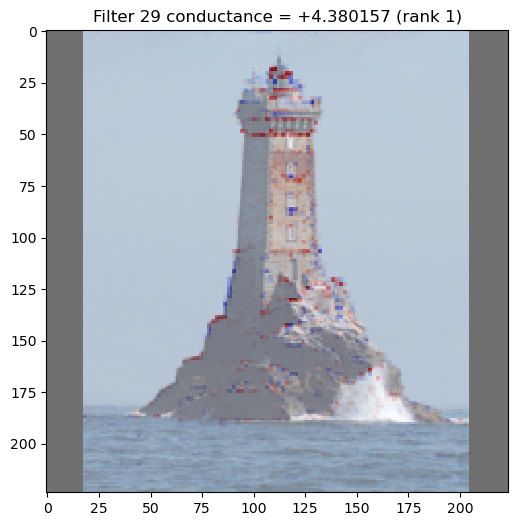

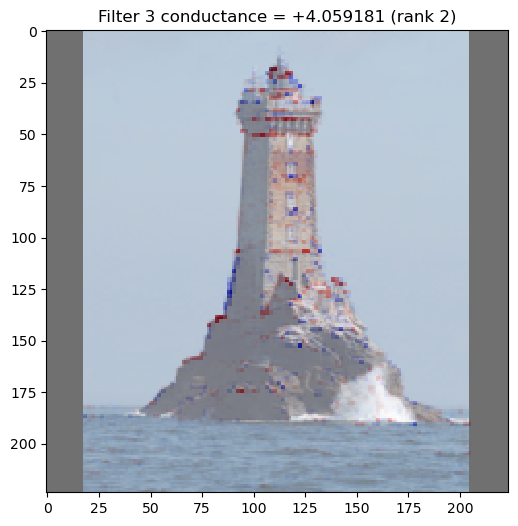

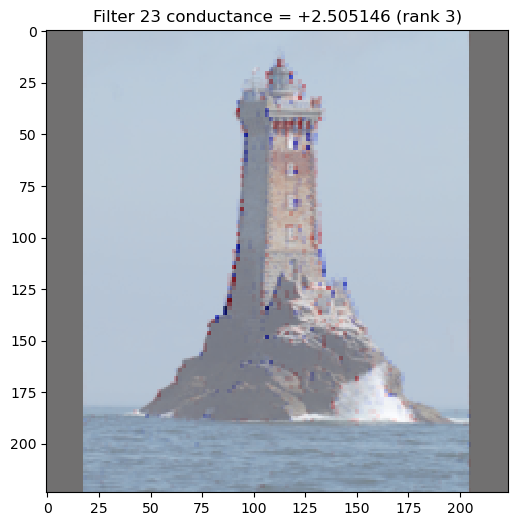

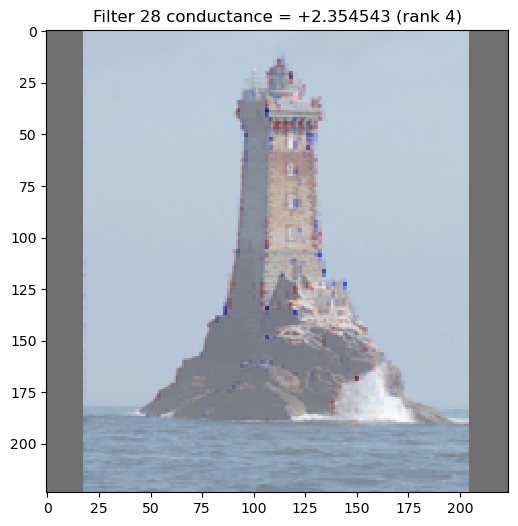

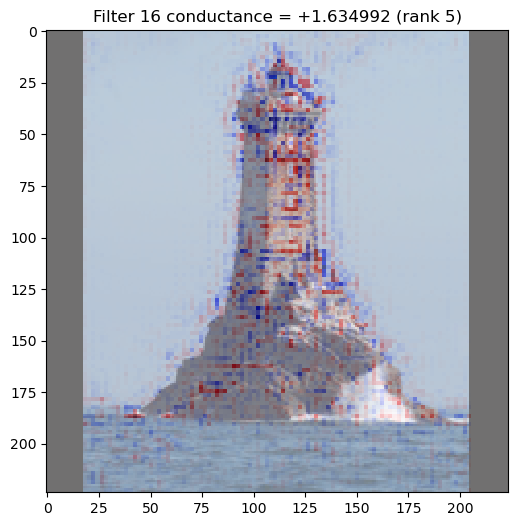

In [34]:
result = run_conductance_pipeline(
    image_path="data/lighthouse.jpg",
    layer_name='model.0',
    n_steps=128,
    top_n=5,
)

In [39]:
def sample_integrand_curve(
    image_path,
    layer_name,
    num_points=101,
    fd_eps=1e-3,
):
    x, _ = load_image(image_path)
    x0 = black_baseline_like(x)
    delta_x = (x - x0).contiguous()

    hook = LayerHook(model, layer_name)

    def forward_with_layer(x_in):
        hook.clear()
        out = model(x_in)
        act = unwrap_tensor(hook.get())
        return out, act

    try:
        with torch.no_grad():
            out, _ = forward_with_layer(x)
            _, logits = split_classifier_output(out)
            target_class = int(logits[0].argmax().item())
            target_name = class_names[target_class]

        alphas = torch.linspace(0.0, 1.0, num_points, device=x.device, dtype=x.dtype)
        values = []

        for alpha in alphas:
            x_alpha = (x0 + alpha * delta_x).contiguous().detach().requires_grad_(True)

            out, act = forward_with_layer(x_alpha)
            _, logits = split_classifier_output(out)
            score = logits[0, target_class]

            grad_y = torch.autograd.grad(score, act, retain_graph=False, create_graph=False)[0]

            try:
                def act_only(inp):
                    inp = inp.contiguous()
                    _, a = forward_with_layer(inp)
                    return a

                _, act_tangent = jvp(act_only, (x_alpha,), (delta_x,))
            except RuntimeError:
                alpha_f = float(alpha.item())
                alpha_plus = min(alpha_f + fd_eps, 1.0)
                alpha_minus = max(alpha_f - fd_eps, 0.0)
                denom = alpha_plus - alpha_minus

                with torch.no_grad():
                    _, act_plus = forward_with_layer((x0 + alpha_plus * delta_x).contiguous())
                    _, act_minus = forward_with_layer((x0 + alpha_minus * delta_x).contiguous())

                act_tangent = (act_plus - act_minus) / denom

            g_alpha = (grad_y * act_tangent).sum().detach().cpu().item()
            values.append(g_alpha)

            del x_alpha, out, act, logits, score, grad_y, act_tangent
            hook.clear()

        return {
            "alphas": alphas.detach().cpu().numpy(),
            "values": np.array(values, dtype=np.float64),
            "target_class": target_class,
            "target_name": target_name,
        }
    finally:
        hook.remove()
        clear_backend_cache()

In [40]:
curve = sample_integrand_curve("data/jess.jpg", "model.5", num_points=201)

plt.figure(figsize=(8, 4))
plt.plot(curve["alphas"], curve["values"])
plt.title(f"g(alpha) for {curve['target_name']}")
plt.xlabel("alpha")
plt.ylabel("dF/dalpha")
plt.grid(True)
plt.show()

KeyboardInterrupt: 